In [1]:
# PAV association with BNI trait (Y~PAV)
# author: Sheng-Kai Hsu
# created: 2023.03.29
# last edited: 2023.09.12
# note: update to v3: papalum peptide query -> miniProt -> filter (80% CDS coverage)
# repurposed for a template for panandGWAS script


In [2]:
rm(list=ls())
library(limma)
library(scales)
library(pheatmap)
library(ape)
require(reshape2)
library(dplyr)
library(phytools)
library(geiger)
library(ggtree)
library(stringr)
library(qqman)

require(rMVP)      # R version of the MVP package
source("/workdir/sh2246/p_evolBNI/src/S01_phyloK.R")

Loading required package: reshape2


Attaching package: ‘dplyr’


The following object is masked from ‘package:ape’:

    where


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union


Loading required package: maps


Attaching package: ‘phytools’


The following object is masked from ‘package:scales’:

    rescale


ggtree v3.4.4 For help: https://yulab-smu.top/treedata-book/

If you use the ggtree package suite in published research, please cite
the appropriate paper(s):

Guangchuang Yu, David Smith, Huachen Zhu, Yi Guan, Tommy Tsan-Yuk Lam.
ggtree: an R package for visualization and annotation of phylogenetic
trees with their covariates and other associated data. Methods in
Ecology and Evolution. 2017, 8(1):28-36. doi:10.1111/2041-210X.12628

Guangchuang Yu. Using ggtree to visualize data on tree-like structures.
Current Protocols in Bioinformatics. 2020, 69:e96. doi:1

In [3]:
GWAS=function(P,G,K,map,nPC=0,method="GLM",CV=NULL){
  # preparing the inputs (PAV, K matrix and map) according to MVP needs
  
  genotype_PAV     = as.big.matrix(G) # dimension: PAV x samples
  genotype_Kmatrix = as.big.matrix(K)           # dimension: samples x samples
  
  # perenniality  # data.frame, dimension: samples x (sample id + traits)
  # map_panand2   # data.frame, dimension: PAVs x 3 (gene, chr and position)
  
  #head(map_panand2)
  #map_panand2$chr = as.numeric(gsub(map_panand2$chr,pattern = 'chr',replacement = '')) # ignore it. does not matter
  
  GWAS_perenniality <- rMVP::MVP(
    # Data Inputs 
    phe  = P, 
    geno = genotype_PAV,
    K    = genotype_Kmatrix,
    map  = map,
    CV.GLM = CV, CV.MLM = CV,  
    
    # Method 
    method=method, 
    
    # Number of Principal components for each mode ---
    nPC.GLM = nPC, nPC.MLM = nPC,
    
    # Threshold 
    permutation.threshold = F, threshold = 0.05,
    
    # Outputs and computing parameters
    file.output=F, ncpus=8)
}


In [4]:
# phenotype processing
dat=read.csv("/workdir/sh2246/p_evolBNI/data/Cornell_PNRandNitrateAssay.csv",header = T)
annualSp=c("Zea mays","Sorghum bicolor","Thelepogon elegans")

#BNI calculation
dat$taxa=strsplit2(dat$plantID_repl.,"_")[,1]
control=median(dat$PNR[dat$taxa=="blank"])
dat$spTaxa=paste0(dat$taxa,": ",dat$species.name)
dat$BNI=(1-dat$PNR/control)*100

#Nitrate conversion
dat$soilN_mgN=dat$soilN*0.005/(0.002*(1-dat$SoilMoisture_dw*dat$DSW/dat$FSW))
dat$resinN_mgN=dat$resinN*0.005/0.002

dat_N_std=c(7.871,7.834,8.024,
            1.4,1.424,1.382,
            0.675,0.66,0.664)

#filtering
dat_filtered=dat[dat$inTree!=0&dat$condition!=0&!dat$plantID%in%c("A10260002","A10280002","A10310002"),]


In [5]:
se=function(x) sd(x)/sqrt(length(x))
BNI_avg=tapply(dat_filtered$BNI,dat_filtered$taxa,median)
BNI_se=tapply(dat_filtered$BNI,dat_filtered$taxa,se)

soilN_avg=tapply(dat_filtered$soilN_mgN,dat_filtered$taxa,median)
soilN_se=tapply(dat_filtered$soilN_mgN,dat_filtered$taxa,se)

resinN_avg=tapply(dat_filtered$resinN_mgN,dat_filtered$taxa,median)
resinN_se=tapply(dat_filtered$resinN_mgN,dat_filtered$taxa,se)

pwN_T0_avg=tapply(dat_filtered$T0,dat_filtered$taxa,median)
pwN_T0_se=tapply(dat_filtered$T0,dat_filtered$taxa,se)
pwN_T1_avg=tapply(dat_filtered$T1,dat_filtered$taxa,median)
pwN_T1_se=tapply(dat_filtered$T1,dat_filtered$taxa,se)
pwN_T2_avg=tapply(dat_filtered$T2,dat_filtered$taxa,median)
pwN_T2_se=tapply(dat_filtered$T2,dat_filtered$taxa,se)
pwN_T3_avg=tapply(dat_filtered$T3,dat_filtered$taxa,median)
pwN_T3_se=tapply(dat_filtered$T3,dat_filtered$taxa,se)


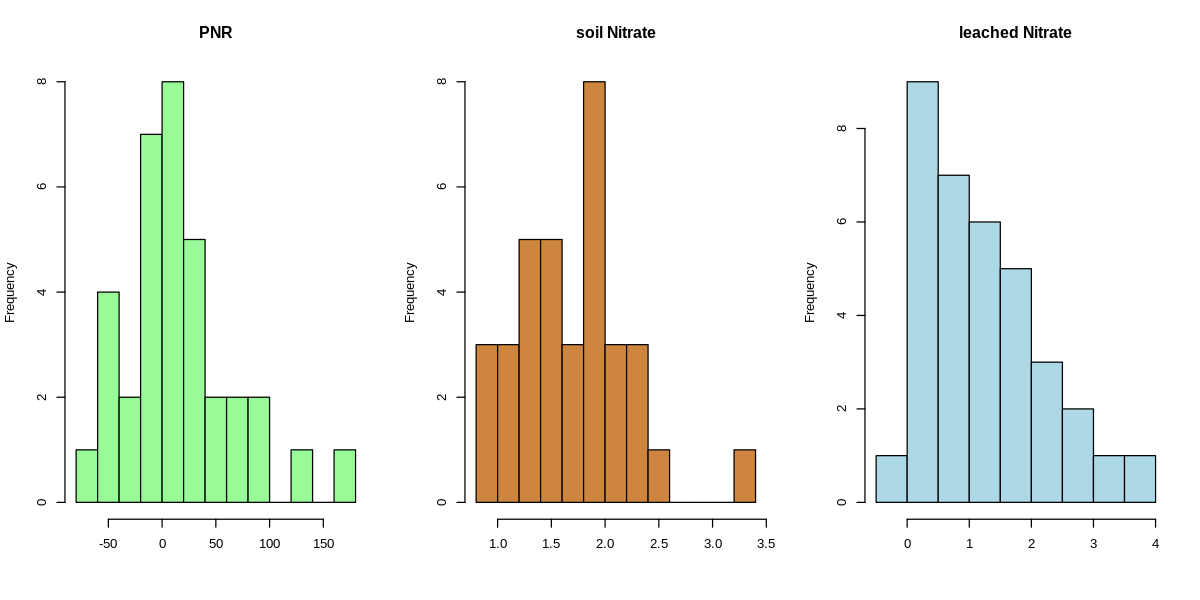

In [6]:
options(repr.plot.width=10, repr.plot.height=5)
par(mfrow=c(1,3))
hist(-BNI_avg,breaks = 10,main = "PNR",xlab = "",col="palegreen")
hist(log(soilN_avg+0.01),breaks = 10,main = "soil Nitrate",xlab = "",col = "tan3")
hist(log(resinN_avg+0.01),breaks = 10,main = "leached Nitrate",xlab = "",col = "lightblue")

In [7]:
#phenotype matrix generation
pheno=data.frame(sample=names(BNI_avg),PNR=-BNI_avg,soilN =soilN_avg,resinN=resinN_avg)
pheno1=data.frame(sample=names(BNI_avg),pheno=BNI_avg)
pheno2=data.frame(sample=names(soilN_avg),pheno=log(soilN_avg+0.01))
pheno3=data.frame(sample=names(resinN_avg),pheno=log(resinN_avg+0.01))

In [8]:
metadata=read.csv("/workdir/sh2246/p_evolBNI/data/BNITaxa_translateTable.csv",header = T)

In [9]:
#load genomic PAV data
pav=read.table("/workdir/sh2246/p_evolBNI/output/PAV_CNV/Pv_miniProt_PAV.txt",header = T)

In [10]:
#name matching
merge_tab=data.frame(Sample=strsplit2(gsub("X","",colnames(pav)),split = "_|.final")[,1])
metadata$Sample=gsub("-",".",strsplit2(metadata$genome_path,split = "_|.final|.fa")[,1])
metadata$spTaxa=paste0(metadata$Plant_ID,": ",metadata$species.name)
merge_tab=merge(merge_tab,metadata,by = "Sample")
merge_tab=merge_tab[!duplicated(merge_tab$Sample),]
rownames(merge_tab)=merge_tab$Sample
merge_tab=merge_tab[strsplit2(gsub("X","",colnames(pav)),split = "_|.final")[,1],]

colnames(pav)=merge_tab$Plant_ID

In [11]:
# neutral tree input and renaming
rootedtree1 = read.tree("/workdir/sh2246/p_evolBNI/output/speciesTrees_median4dD_v2.newick")

rootedtree1.renamed=rootedtree1
rootedtree1.renamed$tip.label = gsub("-",".",rootedtree1.renamed$tip.label)
rootedtree1.renamed$tip.label = merge_tab[rootedtree1.renamed$tip.label,]$Plant_ID
rootedtree1.renamed$tip.label

[1] "A10630002" "A1114002"  "A11070002" "A10980002" "A10680002" "A11050002"
 [7] "A11060002" "A10880002" "A10250002" "A11100002" "A10160002" "A10870002"
[13] "A10960002" "A10740002" "A10100002" "A10200002" "A10990002" "A10300002"
[19] "Btx623"    "A10330002" "A10860002" "A11090002" "A10130002" "A10140002"
[25] "A10730002" "A10230002" "A10150002" "A10210002" "A10760002" "A10770002"
[31] "A11080002" "B73"       "Mo17"      "T062"      NA

In [12]:
#load gff for position mapping
gff=read.delim("/workdir/sh2246/p_evolBNI/data/Pvaginatum_672_v3.1.gene_exons_modified_sorted2.gff3",header = F)
gff_genePos=gff[gff$V3=="mRNA",]
rownames(gff_genePos)=gsub("ID=","",strsplit2(gff_genePos$V9,";")[,1])

In [13]:
#position mapping and PAV filtering
map = data.frame(gene=rownames(gff_genePos),chr = gff_genePos[,1],POS=gff_genePos[,4])
map=map[grep("Chr",map$chr),]
map$gene = as.character(map$gene)
map = map [map$gene %in% rownames(pav),]

PAVUsed=pav[map$gene,colnames(pav)%in% rootedtree1.renamed$tip.label]
PAVUsed=PAVUsed[,colSums(PAVUsed)>30000]
PAVUsed=PAVUsed[rowSums(PAVUsed)>1&rowSums(PAVUsed)<(33-6),]

map2=map[map$gene%in%rownames(PAVUsed),]


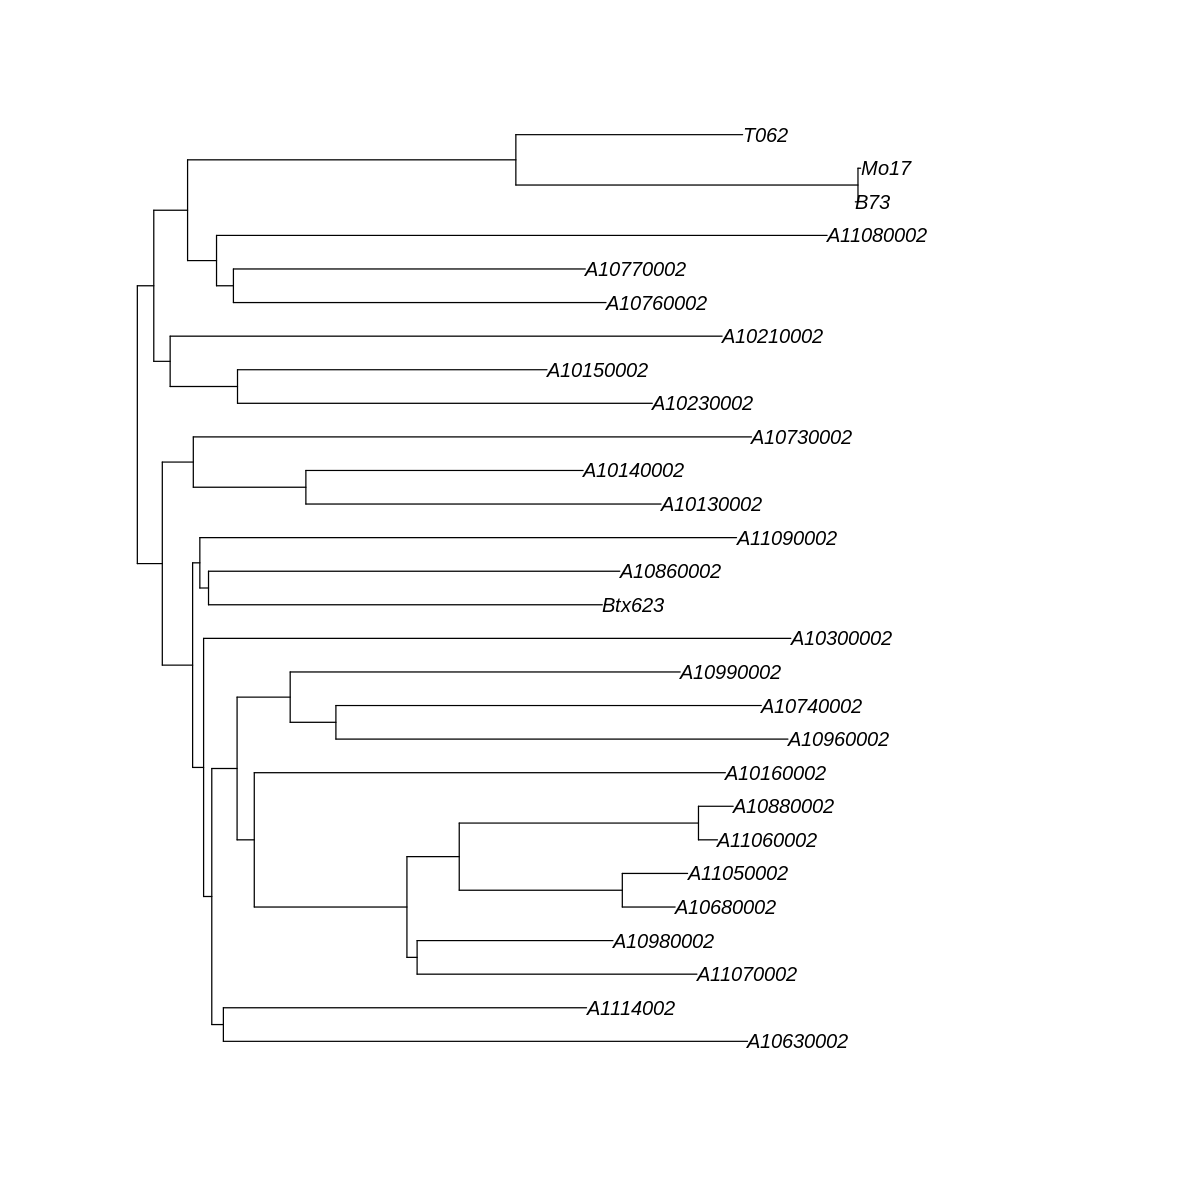

In [14]:
options(repr.plot.width=10, repr.plot.height=10)
rootedtree1.renamed$tip.label[35] = "ref"
inputTree=keep.tip(rootedtree1.renamed,colnames(PAVUsed))
plot(inputTree,use.edge.length = T)

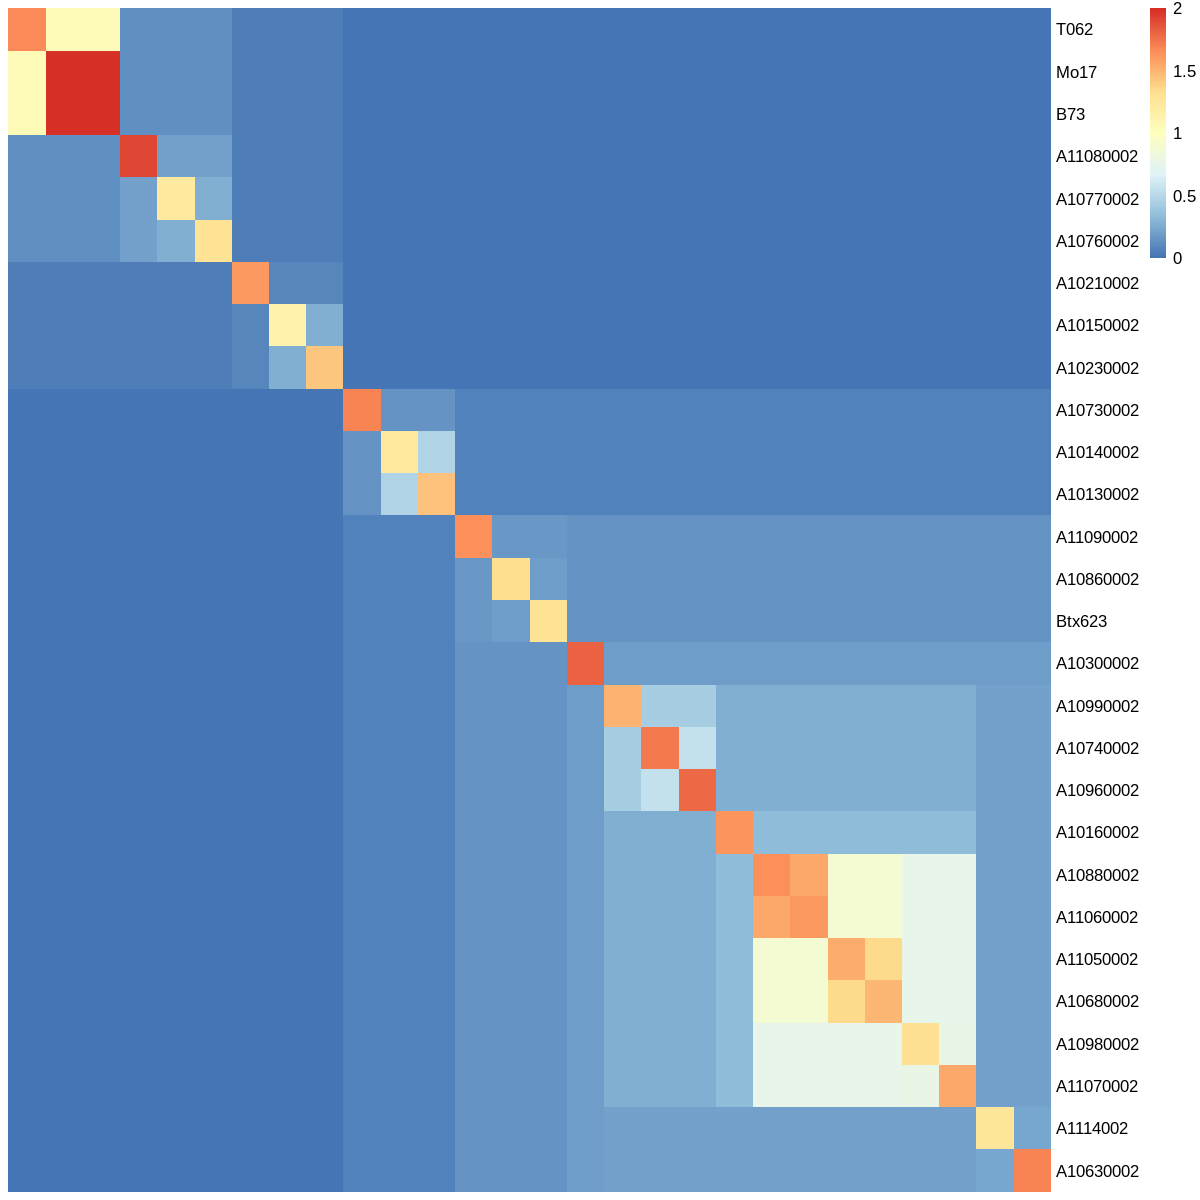

In [15]:
#phyloK calculation
K=phyloK(inputTree )
colnames(K)=rownames(K)
pheatmap(K[rev(inputTree$tip.label),rev(inputTree$tip.label)],cluster_cols = F,cluster_rows = F,
         show_rownames = T,show_colnames = F,border_color = NA)

In [16]:
# run GWAS
res=GWAS(pheno1[colnames(PAVUsed[,inputTree$tip.label]),],PAVUsed[,inputTree$tip.label],K,map2,method = c("GLM","MLM"))
res2=GWAS(pheno2[colnames(PAVUsed[,inputTree$tip.label]),],PAVUsed[,inputTree$tip.label],K,map2,method = c("GLM","MLM"))
res3=GWAS(pheno3[colnames(PAVUsed[,inputTree$tip.label]),],PAVUsed[,inputTree$tip.label],K,map2,method = c("GLM","MLM"))


Warning message in as.big.matrix(G):
“Coercing data.frame to matrix via factor level numberings.”


====================== Welcome to MVP ======================
      A Memory-efficient, Visualization-enhanced, and       
             Parallel-accelerated Tool For GWAS             
                    __  __  __   __  ___                    
                   |  \/  | \ \ / / | _ \                   
                   | |\/| |  \ V /  |  _/                   
                   |_|  |_|   \_/   |_|     Version: 1.0.6  
  Designed and Maintained by Lilin Yin, Haohao Zhang, and   
  Xiaolei Liu                                               
  Contributors: Zhenshuang Tang, Jingya Xu, Dong Yin,       
  Zhiwu Zhang, Xiaohui Yuan, Mengjin Zhu, Shuhong Zhao,     
  Xinyun Li                                                 
  Contact: xiaoleiliu@mail.hzau.edu.cn                      
Start: 2023-09-12 10:19:50 
Input data has 28 individuals, 8415 markers 
Analyzed trait: pheno 
Number of threads used: 8 
Total 2 individuals removed due to missings 
Eigen Decomposition on GRM 
-----------

Warning message in as.big.matrix(G):
“Coercing data.frame to matrix via factor level numberings.”


====================== Welcome to MVP ======================
      A Memory-efficient, Visualization-enhanced, and       
             Parallel-accelerated Tool For GWAS             
                    __  __  __   __  ___                    
                   |  \/  | \ \ / / | _ \                   
                   | |\/| |  \ V /  |  _/                   
                   |_|  |_|   \_/   |_|     Version: 1.0.6  
  Designed and Maintained by Lilin Yin, Haohao Zhang, and   
  Xiaolei Liu                                               
  Contributors: Zhenshuang Tang, Jingya Xu, Dong Yin,       
  Zhiwu Zhang, Xiaohui Yuan, Mengjin Zhu, Shuhong Zhao,     
  Xinyun Li                                                 
  Contact: xiaoleiliu@mail.hzau.edu.cn                      
Start: 2023-09-12 10:19:53 
Input data has 28 individuals, 8415 markers 
Analyzed trait: pheno 
Number of threads used: 8 
Total 2 individuals removed due to missings 
Eigen Decomposition on GRM 
-----------

Warning message in as.big.matrix(G):
“Coercing data.frame to matrix via factor level numberings.”


====================== Welcome to MVP ======================
      A Memory-efficient, Visualization-enhanced, and       
             Parallel-accelerated Tool For GWAS             
                    __  __  __   __  ___                    
                   |  \/  | \ \ / / | _ \                   
                   | |\/| |  \ V /  |  _/                   
                   |_|  |_|   \_/   |_|     Version: 1.0.6  
  Designed and Maintained by Lilin Yin, Haohao Zhang, and   
  Xiaolei Liu                                               
  Contributors: Zhenshuang Tang, Jingya Xu, Dong Yin,       
  Zhiwu Zhang, Xiaohui Yuan, Mengjin Zhu, Shuhong Zhao,     
  Xinyun Li                                                 
  Contact: xiaoleiliu@mail.hzau.edu.cn                      
Start: 2023-09-12 10:19:56 
Input data has 28 individuals, 8415 markers 
Analyzed trait: pheno 
Number of threads used: 8 
Total 2 individuals removed due to missings 
Eigen Decomposition on GRM 
-----------

In [17]:
head(res$glm.results)

Effect,SE,pheno.GLM
-5.894384,28.25393,0.83650403
-26.843372,27.74363,0.34291854
4.403579,41.81635,0.91700695
-25.701298,22.83228,0.27144208
-64.545776,39.69666,0.11701568
-51.721900,19.70706,0.01485558


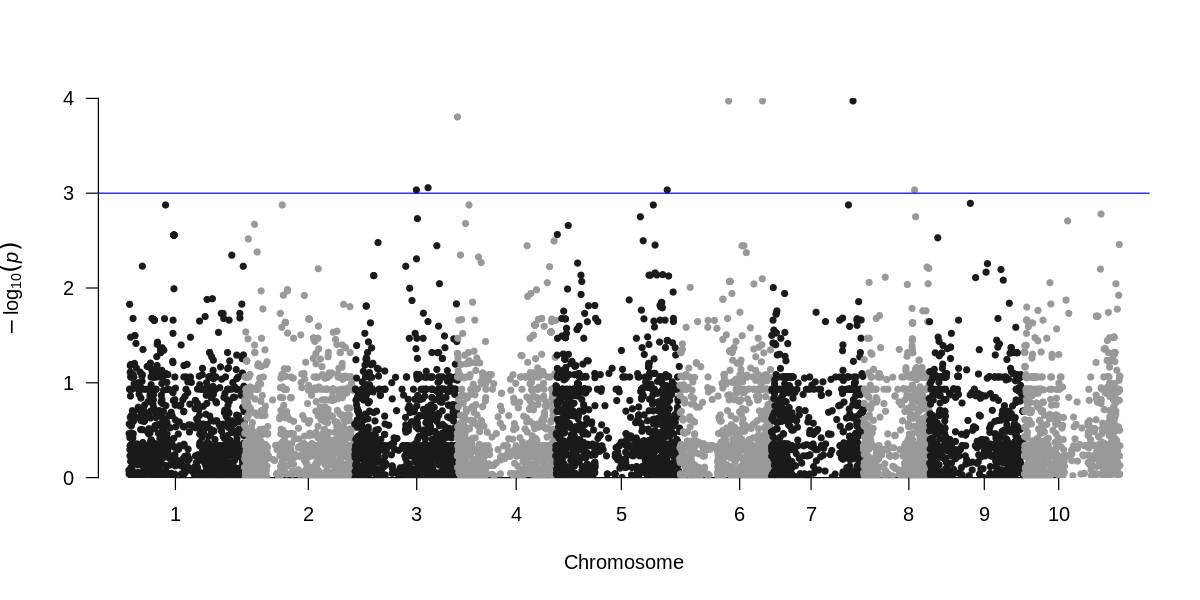

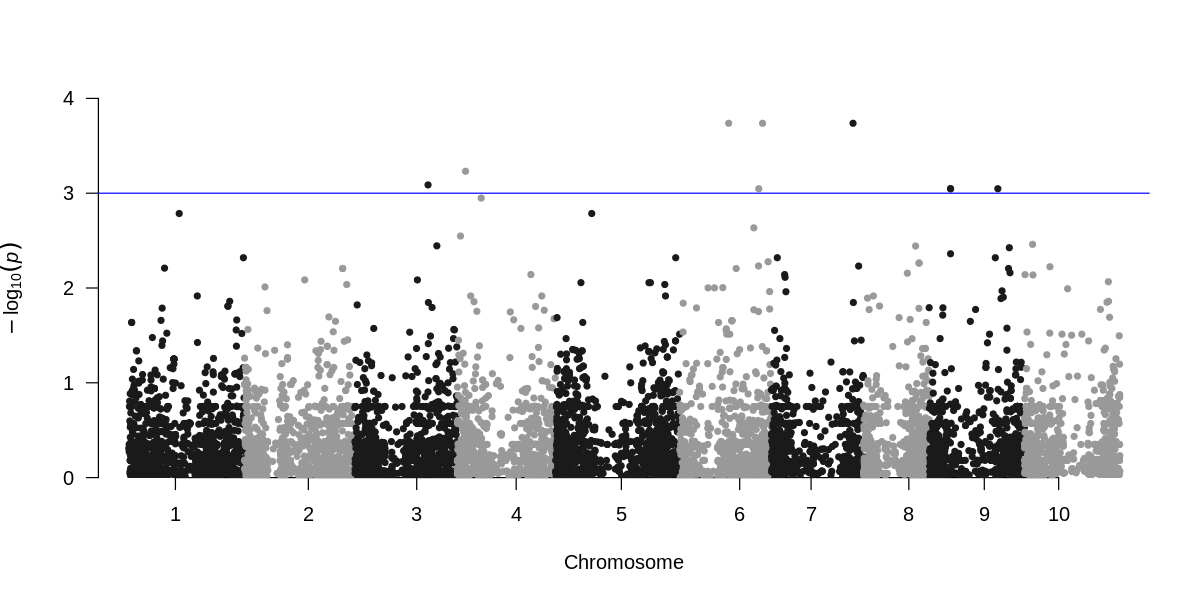

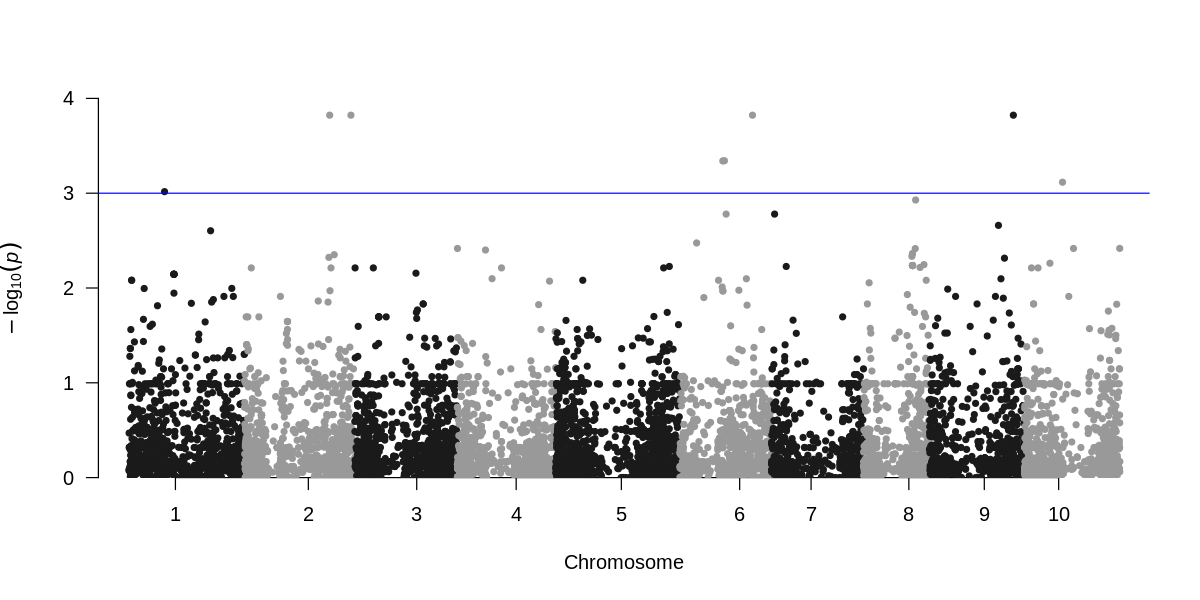

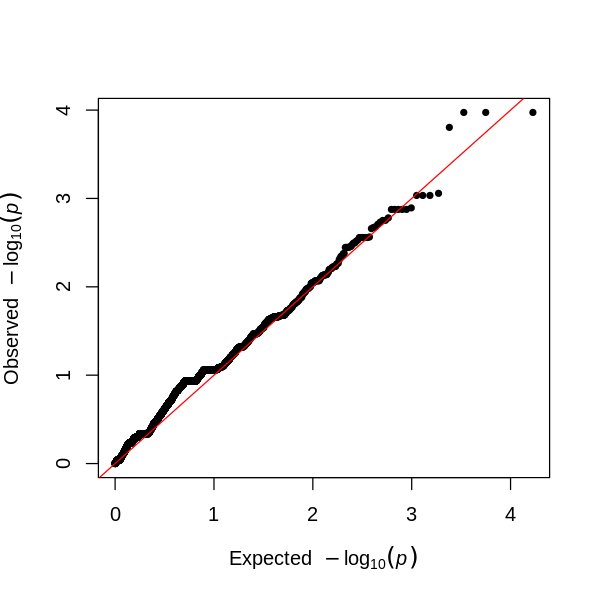

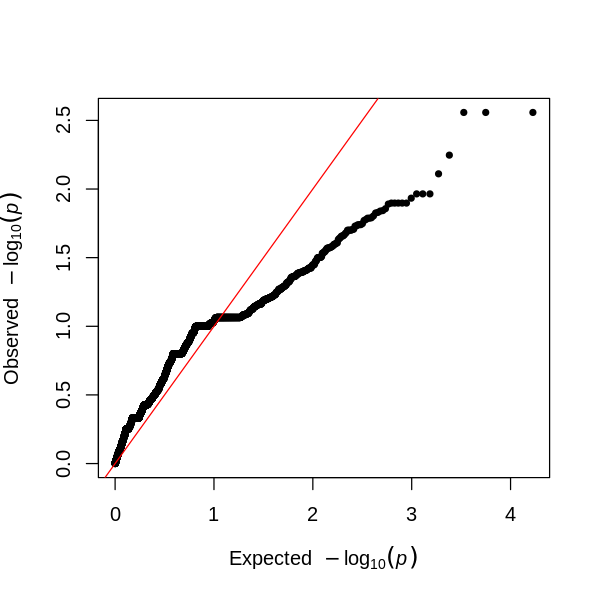

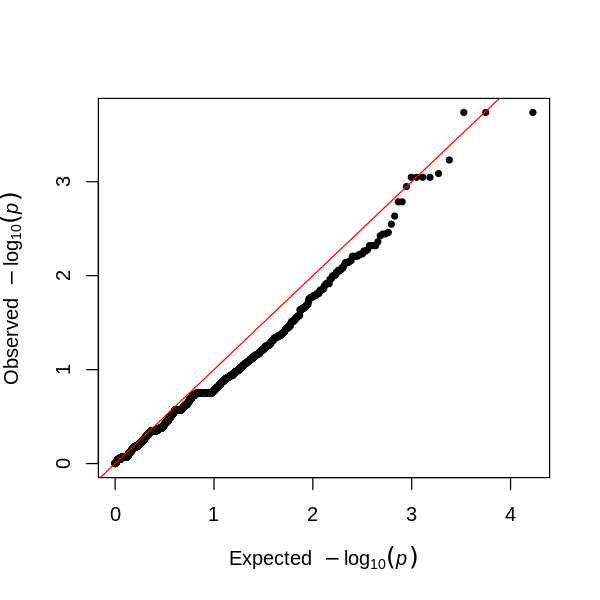

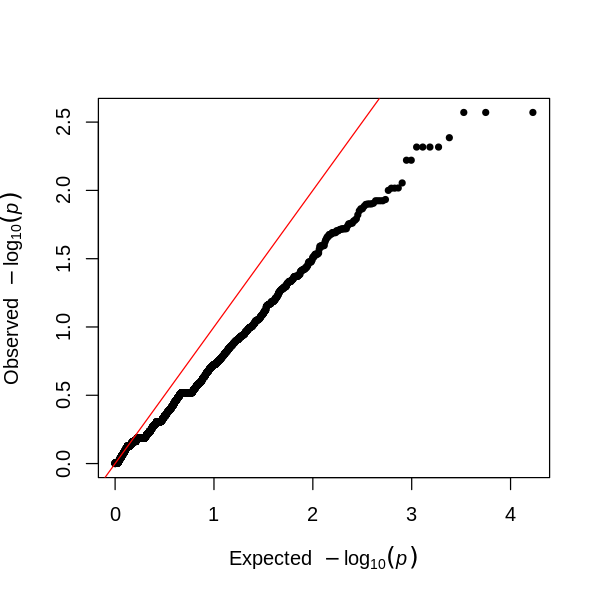

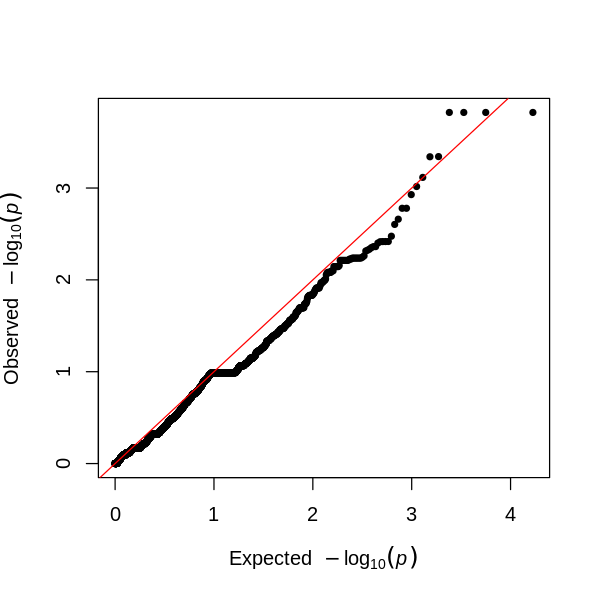

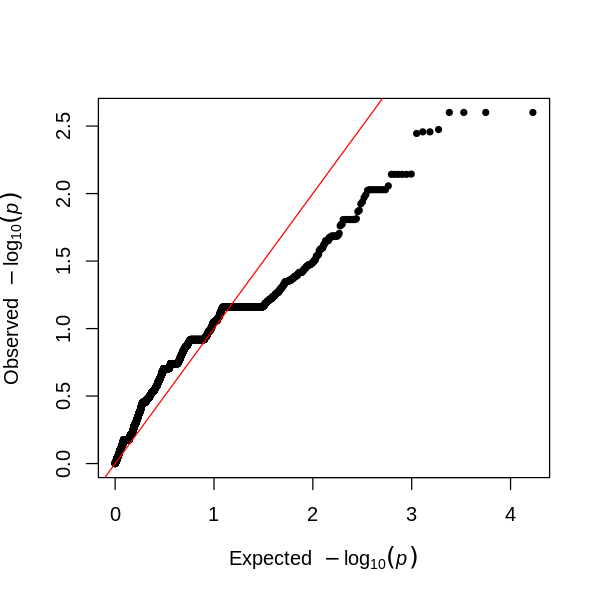

In [19]:
# manhattan and qq plot
res_glm=data.frame(Chr=as.numeric(gsub("Chr","",map2$chr)),BP=map2$POS,P_PNR=as.numeric(res$glm.results[,3]),
                   P_soil=as.numeric(res2$glm.results[,3]),P_resin=as.numeric(res3$glm.results[,3]), Gene=map2$gene)
res_mlm=data.frame(Chr=as.numeric(gsub("Chr","",map2$chr)),BP=map2$POS,P_PNR=as.numeric(res$mlm.results[,3]),
                   P_soil=as.numeric(res2$mlm.results[,3]),P_resin=as.numeric(res3$mlm.results[,3]), Gene=map2$gene)

options(repr.plot.width=10, repr.plot.height=5)
manhattan(na.omit(res_glm),chr = "Chr",bp = "BP",p = "P_PNR",snp = "Gene",logp = T,suggestiveline = 3,genomewideline = F)
# manhattan(na.omit(res_mlm),chr = "Chr",bp = "BP",p = "P_PNR",snp = "Gene",logp = T,suggestiveline = 3,genomewideline = F)
manhattan(na.omit(res_glm),chr = "Chr",bp = "BP",p = "P_soil",snp = "Gene",logp = T,suggestiveline = 3,genomewideline = F)
# manhattan(na.omit(res_mlm),chr = "Chr",bp = "BP",p = "P_soil",snp = "Gene",logp = T,suggestiveline = 3,genomewideline = F)
manhattan(na.omit(res_glm),chr = "Chr",bp = "BP",p = "P_resin",snp = "Gene",logp = T,suggestiveline = 3,genomewideline = F)
# manhattan(na.omit(res_mlm),chr = "Chr",bp = "BP",p = "P_resin",snp = "Gene",logp = T,suggestiveline = 3,genomewideline = F)
options(repr.plot.width=5, repr.plot.height=5)
qq(as.numeric(res$glm.results[,3]))
qq(as.numeric(res$mlm.results[,3]))
qq(as.numeric(res2$glm.results[,3]))
qq(as.numeric(res2$mlm.results[,3]))
qq(as.numeric(res3$glm.results[,3]))
qq(as.numeric(res3$mlm.results[,3]))